# Simplified Listener Pipeline
Loads the listener dataset, drops obvious non-feature columns, saves `clean_data.csv`, trains XGBoost and CatBoost once using best params from `best_results.csv`, runs across non-graph, graph-only, and combined feature sets, and shows feature importance plus SHAP for the best model. Only the target uses a log transform; features stay on their original scale.

In [5]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sns.set_theme(style="ticks", palette="deep")
RANDOM_STATE = 42

DATA_PATH = Path("../data/final_df.csv")
TARGET = "followers"

CATEGORICAL_COLS = [
    "primary_label",
    "primary_genre",
    "primary_role",
    "artist_country",
    "artist_region_city",
]

BASE_FEATURES = [
    'releases_total', 'releases_per_year', 'avg_days_between_releases',
    'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
    'max_dry_spell_days', 'front_loading_index', 'tracks_total',
    'label_diversity_count', 'label_churn',
    'label_hhi', 'primary_label', 'duration_ms_mean', 'duration_ms_median',
    'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
    'genre_count', 'genre_entropy', 'primary_genre', 'artist_country',
    'artist_region_city', 'years_active', 'primary_role'
]

GRAPH_FEATURES = [
    'clust_local',
    'triangles', 'open_wedges', 'gwesp_score', 'degree', 'log_degree',
    'eigencent', 'kcore', 'betweenness', 'closeness', 'dist_to_hub_min',
    'same_genre_share', 'same_label_share', 'same_role_share',
    'tri_within_genre', 'tri_within_label', 'tri_within_role',
    'tri_cross_genre', 'tri_cross_label', 'tri_cross_role',
    'component_size', 'open_dyads', 'weak_tie_frac',
    'community_participation', 'collab_track_rate'
]

NODE2VEC_FEATURES = [f'n2v_{i}' for i in range(32)]
MISSING_THRESHOLD = 0.30

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV not found at {DATA_PATH.resolve()}")


/home/woodbkb2/git/nepo-music/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load raw data

In [6]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns from {DATA_PATH.name}")
display(raw_df.head())


Loaded 86,843 rows and 84 columns from final_df.csv


,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,label_diversity_count,label_churn,label_hhi,primary_label,duration_ms_mean,duration_ms_median,duration_ms_min,duration_ms_max,remix_rate,acoustic_rate,genre_count,genre_entropy,primary_genre,artist_country,artist_region_city,years_active,primary_role,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,closeness,dist_to_hub_min,same_genre_share,same_label_share,same_role_share,tri_within_genre,tri_within_label,tri_within_role,tri_cross_genre,tri_cross_label,tri_cross_role,component_size,open_dyads,weak_tie_frac,community_participation,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,n2v_16,n2v_17,n2v_18,n2v_19,n2v_20,n2v_21,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers
0,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,1,0,1.000000,RCA Victor Red Seal,249275.500000,257000.0,80000.0,393653.0,0.000000,0.0,0,NaN,NaN,United States,Chicago,88.917180,arranger,0.054435,27.0,469.0,12.396268,32.0,3.496508,1.587213e-03,26.0,0.000012,0.249735,2.0,0.875000,0.000000,0.218750,21.0,0.0,2.0,0.0,22.0,3.0,223031.0,6858.0,0.625000,0.03125,-0.128991,-1.694535,0.064292,-0.646665,0.099127,0.051858,0.970315,0.116035,-0.620769,0.111918,-0.204037,-0.291270,0.554467,-0.538593,-0.461660,0.489614,0.388579,1.197057,-0.884752,0.922790,-0.792016,0.474416,0.505118,-1.160771,-0.132201,-0.456440,-0.137569,1.924753,0.072517,-0.457421,0.448606,-1.264607,1370.0
1,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,16,27,0.234568,Columbia Records,167655.661290,173800.0,100000.0,174906.0,0.000000,0.0,2,0.693147,pop,Italy,Città di Castello,62.086242,composer,0.226316,43.0,147.0,14.098771,20.0,3.044522,1.622286e-04,15.0,0.000010,0.243299,2.0,0.050000,0.050000,0.200000,0.0,0.0,0.0,0.0,27.0,19.0,223031.0,1236.0,0.300000,0.25000,0.609458,-0.210220,0.052727,0.579634,-0.037742,-0.738730,0.011617,-0.182715,-0.157036,0.317899,0.128215,-0.219891,-0.559873,0.467212,-0.495910,0.295817,-0.169684,-0.095249,-0.254201,0.001349,1.507486,0.825720,0.290062,-1.179892,-0.255170,-0.150105,-0.182942,1.127504,-0.696789,0.231541,-0.249587,-0.199662,556472.0
2,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,1,0,1.000000,West One Music,207631.285714,214000.0,79061.0,279000.0,0.000000,0.0,0,NaN,NaN,London,NaN,11.507187,composer,1.000000,3.0,0.0,1.896362,3.0,1.386294,3.260441e-12,3.0,0.000000,0.131257,6.0,1.000000,1.000000,0.666667,3.0,3.0,1.0,0.0,0.0,0.0,223031.0,7.0,0.000000,0.00000,1.073059,-0.640525,1.345335,0.583744,0.124331,-0.809841,0.334285,-0.138737,-0.275287,0.405015,0.468528,-1.144796,0.535972,-0.205606,-0.026480,0.454535,-0.482318,0.091157,-1.067833,1.194702,-0.468392,-0.121019,0.862476,-0.854992,-0.186828,-0.115647,0.214473,0.727066,1.045198,0.225262,-0.409883,0.464411,5.0
3,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,1,0,1.000000,New State Music,247600.000000,247600.0,247600.0,247600.0,0.000000,0.0,0,NaN,NaN,United Kingdom,NaN,14.165640,unknown,1.000000,1.0,0.0,0.786939,2.0,1.098612,1.161562e-35,2.0,0.000000,0.000000,inf,1.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.000000,0.00000,1.353536,-0.929143,-0.259331,0.737165,0.222830,-0.247469,1.070196,1.039598,0.284260,0.597266,0.904122,0.336391,-0.033738,0.343778,-0.176470,0.632080,0.250941,1.105408,-0.988778,0.250286,0.099882,-0.630041,0.421247,-0.985278,0.345310,-0.987700,0.472917,0.345142,0.180629,-0.121705,0.076498,-0.983664,294.0
4,52,14.443346,23.411765,16.307140,11.0,31.101464,118.0,0.692308,84,0.666667,16,22,0.161243,Lofi Records,146776.095238,136721.0,100500.0,231000.0,0.095238,0.0,8,2.079442,boom bap,London,NaN,3.600274,composer,0.110924,66.0,529.0,27.427670,35.0,3.583519,1.072141e-05,14.0,0.000065,0.206836,2.0,0.457143,0.171429,0.400000,

Top 1% follower threshold: 6003109.600000007


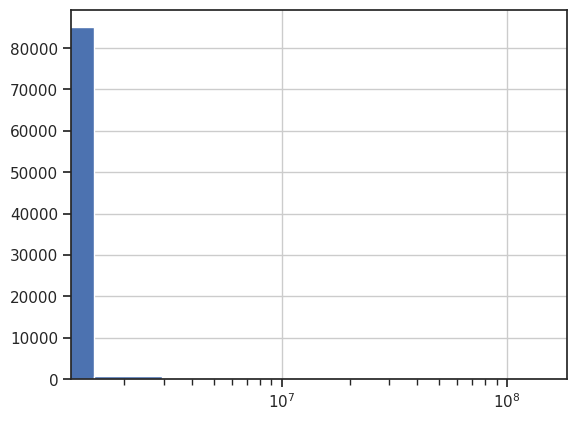

In [7]:
threshold = raw_df[TARGET].quantile(0.995)
print("Top 1% follower threshold:", threshold)
raw_df[TARGET].describe()
raw_df[TARGET].hist(bins=100)
plt.xscale("log")


## Clean columns and save clean_data.csv

In [8]:
df = raw_df.copy()

threshold = df[TARGET].quantile(0.995)
df = df[df[TARGET] <= threshold].copy()

cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
for col in cat_cols:
    df[col] = df[col].fillna('unknown')
    df[col] = df[col].astype("category")

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' not found after dropping columns")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df[TARGET] += 1
df = df.dropna(subset=[TARGET])

numeric_cols = [c for c in df.columns if c not in cat_cols + [TARGET]]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")


missing_rate = df.isna().mean()
high_missing = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
if high_missing:
    print(f"Dropping columns with >{int(MISSING_THRESHOLD*100)}% missing: {high_missing}")
    df = df.drop(columns=high_missing)
    cat_cols = [c for c in cat_cols if c not in high_missing]
    numeric_cols = [c for c in numeric_cols if c not in high_missing]

# Replace inf/-inf with NaN (models handle NaN directly)
df = df.replace([np.inf, -np.inf], np.nan)

clean_path = Path("clean_data.csv")
df.to_csv(clean_path, index=False)
print(f"Cleaned data shape: {df.shape}, saved to {clean_path}")
display(df.head())


Dropping columns with >30% missing: ['genre_entropy']
Cleaned data shape: (86297, 83), saved to clean_data.csv


,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,label_diversity_count,label_churn,label_hhi,primary_label,duration_ms_mean,duration_ms_median,duration_ms_min,duration_ms_max,remix_rate,acoustic_rate,genre_count,primary_genre,artist_country,artist_region_city,years_active,primary_role,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,closeness,dist_to_hub_min,same_genre_share,same_label_share,same_role_share,tri_within_genre,tri_within_label,tri_within_role,tri_cross_genre,tri_cross_label,tri_cross_role,component_size,open_dyads,weak_tie_frac,community_participation,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,n2v_16,n2v_17,n2v_18,n2v_19,n2v_20,n2v_21,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers
0,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,1,0,1.000000,RCA Victor Red Seal,249275.500000,257000.0,80000.0,393653.0,0.000000,0.0,0,unknown,United States,Chicago,88.917180,arranger,0.054435,27.0,469.0,12.396268,32.0,3.496508,1.587213e-03,26.0,0.000012,0.249735,2.0,0.875000,0.000000,0.218750,21.0,0.0,2.0,0.0,22.0,3.0,223031.0,6858.0,0.625000,0.03125,-0.128991,-1.694535,0.064292,-0.646665,0.099127,0.051858,0.970315,0.116035,-0.620769,0.111918,-0.204037,-0.291270,0.554467,-0.538593,-0.461660,0.489614,0.388579,1.197057,-0.884752,0.922790,-0.792016,0.474416,0.505118,-1.160771,-0.132201,-0.456440,-0.137569,1.924753,0.072517,-0.457421,0.448606,-1.264607,1371.0
1,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,16,27,0.234568,Columbia Records,167655.661290,173800.0,100000.0,174906.0,0.000000,0.0,2,pop,Italy,Città di Castello,62.086242,composer,0.226316,43.0,147.0,14.098771,20.0,3.044522,1.622286e-04,15.0,0.000010,0.243299,2.0,0.050000,0.050000,0.200000,0.0,0.0,0.0,0.0,27.0,19.0,223031.0,1236.0,0.300000,0.25000,0.609458,-0.210220,0.052727,0.579634,-0.037742,-0.738730,0.011617,-0.182715,-0.157036,0.317899,0.128215,-0.219891,-0.559873,0.467212,-0.495910,0.295817,-0.169684,-0.095249,-0.254201,0.001349,1.507486,0.825720,0.290062,-1.179892,-0.255170,-0.150105,-0.182942,1.127504,-0.696789,0.231541,-0.249587,-0.199662,556473.0
2,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,1,0,1.000000,West One Music,207631.285714,214000.0,79061.0,279000.0,0.000000,0.0,0,unknown,London,unknown,11.507187,composer,1.000000,3.0,0.0,1.896362,3.0,1.386294,3.260441e-12,3.0,0.000000,0.131257,6.0,1.000000,1.000000,0.666667,3.0,3.0,1.0,0.0,0.0,0.0,223031.0,7.0,0.000000,0.00000,1.073059,-0.640525,1.345335,0.583744,0.124331,-0.809841,0.334285,-0.138737,-0.275287,0.405015,0.468528,-1.144796,0.535972,-0.205606,-0.026480,0.454535,-0.482318,0.091157,-1.067833,1.194702,-0.468392,-0.121019,0.862476,-0.854992,-0.186828,-0.115647,0.214473,0.727066,1.045198,0.225262,-0.409883,0.464411,6.0
3,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,1,0,1.000000,New State Music,247600.000000,247600.0,247600.0,247600.0,0.000000,0.0,0,unknown,United Kingdom,unknown,14.165640,unknown,1.000000,1.0,0.0,0.786939,2.0,1.098612,1.161562e-35,2.0,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.000000,0.00000,1.353536,-0.929143,-0.259331,0.737165,0.222830,-0.247469,1.070196,1.039598,0.284260,0.597266,0.904122,0.336391,-0.033738,0.343778,-0.176470,0.632080,0.250941,1.105408,-0.988778,0.250286,0.099882,-0.630041,0.421247,-0.985278,0.345310,-0.987700,0.472917,0.345142,0.180629,-0.121705,0.076498,-0.983664,295.0
4,52,14.443346,23.411765,16.307140,11.0,31.101464,118.0,0.692308,84,0.666667,16,22,0.161243,Lofi Records,146776.095238,136721.0,100500.0,231000.0,0.095238,0.0,8,boom bap,London,unknown,3.600274,composer,0.110924,66.0,529.0,27.427670,35.0,3.583519,1.072141e-05,14.0,0.000065,0.206836,2.0,0.457143,0.171429,0.400000,10.0,1.0,5.0,2.0,37.

## Build feature sets (non-graph, graph-only, combined)

In [ ]:
base_features = [f for f in BASE_FEATURES if f in df.columns]
graph_features = [f for f in GRAPH_FEATURES if f in df.columns]
n2v_features = [f for f in NODE2VEC_FEATURES if f in df.columns]

feature_sets = {
    "base": base_features,
    "graph": graph_features,
    "n2v": n2v_features,
    "base+graph": base_features + graph_features,   
    "base+n2v": base_features + n2v_features,
    "graph+n2v": graph_features + n2v_features,
    "base+graph+n2v": base_features + graph_features + n2v_features,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")


base: 25 features
graph: 25 features
n2v: 32 features
base+graph: 50 features
base+n2v: 57 features
graph+n2v: 57 features
base+graph+n2v: 82 features


## Train/test split indices (shared across feature sets)

In [15]:
log_followers = np.log10(df["followers"] + 1)

# 2. Bin into quantiles (e.g., 5 or 10 bins)
# qcut handles heavy tails well
df["follower_bin"] = pd.qcut(
    log_followers,
    q=10,          # deciles; 5 is also common
    duplicates="drop"
)

# 3. Stratified split
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["follower_bin"]
)

print(f"Train rows: {len(train_idx)}, Test rows: {len(test_idx)}")


Train rows: 69037, Test rows: 17260


In [20]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

from scipy.stats import randint, loguniform, uniform

In [ ]:

# ---------------- METRICS (LOG SPACE) ----------------

def evaluate_log(model_name: str, model, X_eval: pd.DataFrame, y_true_log: np.ndarray):
    preds_log = model.predict(X_eval)
    return {
        "model": model_name,
        "rmse_log": float(np.sqrt(mean_squared_error(y_true_log, preds_log))),
        "r2_log": float(r2_score(y_true_log, preds_log)),
    }

neg_rmse_log_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)
r2_log_scorer = make_scorer(r2_score, greater_is_better=True)

FS_KEY = "base+graph+n2v"
cols = feature_sets.get(FS_KEY, [])
if not cols:
    raise ValueError(f'Feature set "{FS_KEY}" not found or empty in feature_sets.')

X = df.loc[:, cols]
y = df[TARGET].astype(float)

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

# log targets
y_train_log = np.log10(y_train.to_numpy())
y_test_log  = np.log10(y_test.to_numpy())

# categorical handling for CatBoost: indices relative to X columns
cat_cols_fs = [c for c in cat_cols if c in cols]
cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

# Base estimator used for search
base_cat = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    cat_features=cat_idx,
    iterations=3000,      # resource for halving; keep a reasonable ceiling
    od_type="Iter",
    thread_count=-1
)

# Search space (smart distributions)
param_distributions = {
    "depth": randint(4, 11),                 # 4..10
    "learning_rate": loguniform(1e-3, 2e-1), # 0.001..0.2
    "l2_leaf_reg": loguniform(1e-1, 1e2),    # 0.1..100
    "subsample": uniform(0.6, 0.4),          # 0.6..1.0
    "rsm": uniform(0.6, 0.4),                # 0.6..1.0 (feature subsampling)
    "min_data_in_leaf": randint(1, 101),     # 1..100
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Successive halving: evaluates many configs cheaply, promotes winners
search = HalvingRandomSearchCV(
    estimator=base_cat,
    param_distributions=param_distributions,
    scoring=r2_log_scorer,  # negate RMSE so "higher is better"
    cv=cv,
    factor=3,
    resource="iterations",
    max_resources=3000,
    min_resources=200,
    random_state=RANDOM_STATE,
    n_jobs=1,        # avoid nested parallelism (CatBoost uses thread_count)
    verbose=1,
    refit=True       # refit best params on full X_train/y_train_log (no early stopping)
)

print("finished initialization")

# NOTE: No use_best_model here. No eval_set here.
# You *may* keep early_stopping_rounds, but without eval_set CatBoost can't do best-model selection.
# Keeping it doesn't help much; safest is to omit it.
search.fit(X_train, y_train_log)

print("finished search fitting")

best_params = search.best_params_
best_from_search = search.best_estimator_  # refit-on-train model (no early stopping)

finished initialization
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 200
max_resources_: 3000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 15
n_resources: 200
Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------
iter: 1
n_candidates: 5
n_resources: 600
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 2
n_candidates: 2
n_resources: 1800
Fitting 5 folds for each of 2 candidates, totalling 10 fits
finished search fitting


## Load best params and train XGBoost/CatBoost for each feature set

In [30]:
# This makes training faster + picks best_iteration properly.
final_cat = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    cat_features=cat_idx,
    od_type="Iter",
    thread_count=-1,
    use_best_model=True
)

final_cat.fit(
    X_train,
    y_train_log,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=200
)

best_cat = final_cat

print("finished final refit")

cv_estimator = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    cat_features=cat_idx,
    od_type="Iter",
    thread_count=-1
)

scorers = {"rmse_log": neg_rmse_log_scorer, "r2_log": r2_log_scorer}
cv_cat = cross_validate(
    cv_estimator,
    X_train,
    y_train_log,
    cv=cv,
    scoring=scorers,
    n_jobs=1,
    error_score="raise",
)

print("finished cross validation")

# ---- Test-set metrics (LOG ONLY) ----
metrics = evaluate_log("catboost", best_cat, X_test, y_test_log)
metrics.update(
    {
        "feature_set": FS_KEY,
        "cv_rmse_log_mean": float(-np.mean(cv_cat["test_rmse_log"])),
        "cv_rmse_log_std":  float(np.std(cv_cat["test_rmse_log"])),
        "cv_r2_log_mean":   float(np.mean(cv_cat["test_r2_log"])),
        "cv_r2_log_std":    float(np.std(cv_cat["test_r2_log"])),
        "best_params": best_params,
        "best_iteration": int(getattr(best_cat, "best_iteration_", -1)),
    }
)

results_df = pd.DataFrame([metrics])
display(results_df)

best_model = best_cat
best_features = X_test
feature_names = list(X_train.columns)

finished final refit
finished cross validation


,model,rmse_log,r2_log,feature_set,cv_rmse_log_mean,cv_rmse_log_std,cv_r2_log_mean,cv_r2_log_std,best_params,best_iteration
0,catboost,1.054273,0.40889,base+graph+n2v,1.070074,0.005511,0.396946,0.006007,"{'depth': 8, 'l2_leaf_reg': 5.75775918750704, ...",456


In [32]:
best_df = pd.read_csv("best_results.csv")


def load_best_params(model_name: str) -> dict:
    row = best_df.loc[best_df["model"] == model_name]
    if row.empty:
        raise ValueError(f"No params for {model_name} in best_results.csv")
    raw = ast.literal_eval(row.iloc[0]["best_params"])
    return {k.split("__")[-1]: v for k, v in raw.items()}


xgb_params = load_best_params("xgboost")
cat_params = load_best_params("catboost")

In [ ]:
final_cat = CatBoostRegressor(
    **cat_params,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    cat_features=cat_idx,
    od_type="Iter",
    thread_count=-1,
    use_best_model=True
)

final_cat.fit(
    X_train,
    y_train_log,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=200
)

best_cat = final_cat

print("finished final refit")

metrics = evaluate_log("catboost", best_cat, X_test, y_test_log)

results_df = pd.DataFrame([metrics])
display(results_df)

finished final refit
finished cross validation


,model,rmse_log,r2_log,feature_set,cv_rmse_log_mean,cv_rmse_log_std,cv_r2_log_mean,cv_r2_log_std,best_params,best_iteration
0,catboost,1.046724,0.417325,base+graph+n2v,1.070074,0.005511,0.396946,0.006007,"{'depth': 8, 'l2_leaf_reg': 5.75775918750704, ...",990


In [34]:

# ---- Test-set metrics (LOG ONLY) ----
metrics = evaluate_log("catboost", best_cat, X_test, y_test_log)
metrics.update(
    {
        "feature_set": FS_KEY,
        "cv_rmse_log_mean": float(-np.mean(cv_cat["test_rmse_log"])),
        "cv_rmse_log_std":  float(np.std(cv_cat["test_rmse_log"])),
        "cv_r2_log_mean":   float(np.mean(cv_cat["test_r2_log"])),
        "cv_r2_log_std":    float(np.std(cv_cat["test_r2_log"])),
        "best_params": best_params,
    }
)

results_df = pd.DataFrame([metrics])
display(results_df)

best_model = best_cat
best_features = X_test
feature_names = list(X_train.columns)

,model,rmse_log,r2_log,feature_set,cv_rmse_log_mean,cv_rmse_log_std,cv_r2_log_mean,cv_r2_log_std,best_params
0,catboost,1.046724,0.417325,base+graph+n2v,1.070074,0.005511,0.396946,0.006007,"{'depth': 8, 'l2_leaf_reg': 5.75775918750704, ..."


In [ ]:
def encode_for_xgb(frame: pd.DataFrame, cat_subset):
    encoded = frame.copy()
    for col in cat_subset:
        cat = pd.Categorical(encoded[col])
        encoded[col] = pd.Series(cat.codes, index=encoded.index).replace(-1, np.nan)
    return encoded


# ---------- LOG-ONLY METRICS ----------

def evaluate_log(model_name: str, model, X_eval: pd.DataFrame, y_true_log):
    preds_log = model.predict(X_eval)
    return {
        "model": model_name,
        "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
        "r2_log": r2_score(y_true_log, preds_log),
    }


def rmse_log_cv(estimator, X, y_true_log):
    preds_log = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y_true_log, preds_log))


def r2_log_cv(estimator, X, y_true_log):
    preds_log = estimator.predict(X)
    return r2_score(y_true_log, preds_log)


# ---------------- RUN ----------------

results = []
trained = {}

for fs_name, cols in feature_sets.items():
    print(fs_name)
    if not cols:
        print(f"Skipping {fs_name} (no features).")
        continue

    X = df.loc[:, cols]
    y = df[TARGET].astype(float)

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    # log targets (ONLY thing we score/store)
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    # categorical handling
    cat_cols_fs = [c for c in cat_cols if c in cols]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

    X_train_xgb = encode_for_xgb(X_train, cat_cols_fs)
    X_test_xgb = encode_for_xgb(X_test, cat_cols_fs)

    # models
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        enable_categorical=True,
        n_jobs=-1,
        **xgb_params,
    )

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        cat_features=cat_idx,
        **cat_params,
    )

    # CV scorers (LOG ONLY)
    scorers = {"rmse_log": rmse_log_cv, "r2_log": r2_log_cv}

    cv_xgb = cross_validate(
        xgb_model,
        X_train_xgb,
        y_train_log,
        cv=5,
        scoring=scorers,
        n_jobs=1,
        error_score="raise",
    )
    cv_cat = cross_validate(
        cat_model,
        X_train,
        y_train_log,
        cv=5,
        scoring=scorers,
        n_jobs=1,
        error_score="raise",
    )

    # fit on full train split (log target)
    xgb_model.fit(X_train_xgb, y_train_log)
    cat_model.fit(X_train, y_train_log)

    # test-set metrics (LOG ONLY)
    metrics = [
        evaluate_log("xgboost", xgb_model, X_test_xgb, y_test_log),
        evaluate_log("catboost", cat_model, X_test, y_test_log),
    ]

    # attach CV summary (LOG ONLY)
    metrics[0].update(
        {
            "cv_rmse_log_mean": -np.mean(cv_xgb["test_rmse_log"]),
            "cv_rmse_log_std": np.std(cv_xgb["test_rmse_log"]),
            "cv_r2_log_mean": np.mean(cv_xgb["test_r2_log"]),
            "cv_r2_log_std": np.std(cv_xgb["test_r2_log"]),
        }
    )
    metrics[1].update(
        {
            "cv_rmse_log_mean": -np.mean(cv_cat["test_rmse_log"]),
            "cv_rmse_log_std": np.std(cv_cat["test_rmse_log"]),
            "cv_r2_log_mean": np.mean(cv_cat["test_r2_log"]),
            "cv_r2_log_std": np.std(cv_cat["test_r2_log"]),
        }
    )

    for m in metrics:
        m["feature_set"] = fs_name
    results.extend(metrics)

    trained[(fs_name, "xgboost")] = {
        "model": xgb_model,
        "X_test": X_test_xgb,
        "feature_names": list(X_train_xgb.columns),
    }
    trained[(fs_name, "catboost")] = {
        "model": cat_model,
        "X_test": X_test,
        "feature_names": list(X_train.columns),
    }

results_df = (
    pd.DataFrame(results)
    .sort_values(["rmse_log", "cv_rmse_log_mean"])
    .reset_index(drop=True)
)
display(results_df)

best_row = results_df.iloc[0]
print(f"Best overall (log metrics): {best_row['model']} on {best_row['feature_set']}")
best_key = (best_row["feature_set"], best_row["model"])
best_bundle = trained[best_key]
best_model = best_bundle["model"]
best_features = best_bundle["X_test"]
feature_names = best_bundle["feature_names"]

base
graph
n2v
base+graph
base+n2v
graph+n2v
base+graph+n2v


,model,rmse_log,r2_log,cv_rmse_log_mean,cv_rmse_log_std,cv_r2_log_mean,cv_r2_log_std,feature_set
0,catboost,2.395206,0.419036,2.388620,0.014523,0.416351,0.007842,base+graph+n2v
1,catboost,2.427051,0.403485,2.419073,0.014852,0.401368,0.008509,base+n2v
2,catboost,2.451359,0.391477,2.444592,0.017060,0.388680,0.008537,base+graph
3,catboost,2.553835,0.339537,2.559710,0.015998,0.329745,0.009175,base
4,catboost,2.577508,0.327235,2.557747,0.005038,0.330795,0.004769,graph+n2v
5,catboost,2.670831,0.277637,2.658034,0.005090,0.277286,0.005387,n2v
6,xgboost,2.690457,0.266981,2.671742,0.006478,0.269820,0.004677,base+graph+n2v
7,catboost,2.714202,0.253986,2.697968,0.009964,0.255432,0.002200,graph
8,xgboost,2.727887,0.246443,2.707555,0.008944,0.250124,0.003604,base+n2v
9,xgboost,2.738383,0.240634,2.724336,0.006763,0.240794,0.004150,base+graph


Best overall (log metrics): catboost on base+graph+n2v


In [ ]:
results_df[results_df['model'] == 'catboost'].sort_values('r2_log').drop(columns=['model'])

,rmse_log,r2_log,cv_rmse_log_mean,cv_rmse_log_std,cv_r2_log_mean,cv_r2_log_std,feature_set
7,2.714202,0.253986,2.697968,0.009964,0.255432,0.002200,graph
5,2.670831,0.277637,2.658034,0.005090,0.277286,0.005387,n2v
4,2.577508,0.327235,2.557747,0.005038,0.330795,0.004769,graph+n2v
3,2.553835,0.339537,2.559710,0.015998,0.329745,0.009175,base
2,2.451359,0.391477,2.444592,0.017060,0.388680,0.008537,base+graph
1,2.427051,0.403485,2.419073,0.014852,0.401368,0.008509,base+n2v
0,2.395206,0.419036,2.388620,0.014523,0.416351,0.007842,base+graph+n2v


In [ ]:

# best_df = pd.read_csv("best_results.csv")


# def load_best_params(model_name: str) -> dict:
#     row = best_df.loc[best_df["model"] == model_name]
#     if row.empty:
#         raise ValueError(f"No params for {model_name} in best_results.csv")
#     raw = ast.literal_eval(row.iloc[0]["best_params"])
#     return {k.split("__")[-1]: v for k, v in raw.items()}


# # Only load CatBoost params now
# cat_params = load_best_params("catboost")


# def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
#     preds_log = model.predict(X_eval)
#     preds = np.expm1(preds_log)
#     return {
#         "model": model_name,
#         "rmse": np.sqrt(mean_squared_error(y_true, preds)),
#         "mae": mean_absolute_error(y_true, preds),
#         "r2": r2_score(y_true, preds),
#         "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
#         "r2_log": r2_score(y_true_log, preds_log),
#     }


# results = []
# trained = {}

# for fs_name, cols in feature_sets.items():
#     print(fs_name)
#     if not cols:
#         print(f"Skipping {fs_name} (no features).")
#         continue

#     X = df.loc[:, cols]
#     y = df[TARGET].astype(float)

#     X_train = X.loc[train_idx]
#     X_test = X.loc[test_idx]
#     y_train = y.loc[train_idx]
#     y_test = y.loc[test_idx]

#     cat_cols_fs = [c for c in cat_cols if c in cols]
#     cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

#     y_train_log = np.log1p(y_train)
#     y_test_log = np.log1p(y_test)

#     cat_model = CatBoostRegressor(
#         loss_function="RMSE",
#         random_seed=RANDOM_STATE,
#         verbose=0,
#         allow_writing_files=False,
#         cat_features=cat_idx,
#         **cat_params,
#     )

#     # Simple train / test (no cross-validation)
#     cat_model.fit(X_train, y_train_log)

#     metrics = evaluate("catboost", cat_model, X_test, y_test, y_test_log)
#     metrics["feature_set"] = fs_name
#     results.append(metrics)

#     trained[(fs_name, "catboost")] = {
#         "model": cat_model,
#         "X_test": X_test,
#         "feature_names": list(X_train.columns),
#     }

# results_df = (
#     pd.DataFrame(results)
#     .sort_values(["rmse", "rmse_log"])
#     .reset_index(drop=True)
# )
# display(results_df)

# best_row = results_df.iloc[0]
# print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
# best_key = (best_row["feature_set"], best_row["model"])
# best_bundle = trained[best_key]
# best_model = best_bundle["model"]
# best_features = best_bundle["X_test"]
# feature_names = best_bundle["feature_names"]

base
graph
n2v
base+graph
base+n2v
graph+n2v
base+graph+n2v


,model,rmse,mae,r2,rmse_log,r2_log,feature_set
0,catboost,395465.375632,86194.966009,0.048301,2.395206,0.419036,base+graph+n2v
1,catboost,400154.216722,87290.855619,0.025599,2.427051,0.403485,base+n2v
2,catboost,401052.235934,87322.962228,0.021221,2.451359,0.391477,base+graph
3,catboost,403073.946223,88175.701478,0.011328,2.577508,0.327235,graph+n2v
4,catboost,407915.811374,89402.400144,-0.012567,2.714202,0.253986,graph
5,catboost,408600.734639,89901.578157,-0.015971,2.670831,0.277637,n2v
6,catboost,408847.364128,89237.118410,-0.017197,2.553835,0.339537,base


Best overall: catboost on base+graph+n2v


In [ ]:
# def encode_for_xgb(frame: pd.DataFrame, cat_subset):
#     encoded = frame.copy()
#     for col in cat_subset:
#         cat = pd.Categorical(encoded[col])
#         encoded[col] = pd.Series(cat.codes, index=encoded.index).replace(-1, np.nan)
#     return encoded


# def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
#     preds_log = model.predict(X_eval)
#     preds = np.expm1(preds_log)
#     return {
#         "model": model_name,
#         "rmse": np.sqrt(mean_squared_error(y_true, preds)),
#         "mae": mean_absolute_error(y_true, preds),
#         "r2": r2_score(y_true, preds),
#         "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
#         "r2_log": r2_score(y_true_log, preds_log),
#     }


# results = []
# trained = {}

# for fs_name, cols in feature_sets.items():
#     print(fs_name)

#     X = df.loc[:, cols]
#     y = df[TARGET].astype(float)

#     X_train = X.loc[train_idx]
#     X_test = X.loc[test_idx]
#     y_train = y.loc[train_idx]
#     y_test = y.loc[test_idx]

#     cat_cols_fs = [c for c in cat_cols if c in cols]
#     cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

#     X_train_xgb = encode_for_xgb(X_train, cat_cols_fs)
#     X_test_xgb = encode_for_xgb(X_test, cat_cols_fs)

#     y_train_log = np.log1p(y_train)
#     y_test_log = np.log1p(y_test)

#     # No best_params here – use whatever fixed/default params you want
#     # xgb_model = XGBRegressor(
#     #     objective="reg:squarederror",
#     #     random_state=RANDOM_STATE,
#     #     tree_method="hist",
#     #     enable_categorical=True,
#     #     n_jobs=-1,
#     # )

#     cat_model = CatBoostRegressor(
#         loss_function="RMSE",
#         random_seed=RANDOM_STATE,
#         verbose=0,
#         allow_writing_files=False,
#         cat_features=cat_idx,
#     )

#     # Train on train set only
#     # xgb_model.fit(X_train_xgb, y_train_log)
#     cat_model.fit(X_train, y_train_log)

#     # Evaluate on test set only
#     metrics = [
#         # evaluate("xgboost", xgb_model, X_test_xgb, y_test, y_test_log),
#         evaluate("catboost", cat_model, X_test, y_test, y_test_log),
#     ]

#     for m in metrics:
#         m["feature_set"] = fs_name
#     results.extend(metrics)

#     # trained[(fs_name, "xgboost")] = {
#     #     "model": xgb_model,
#     #     "X_test": X_test_xgb,
#     #     "feature_names": list(X_train_xgb.columns),
#     # }
#     trained[(fs_name, "catboost")] = {
#         "model": cat_model,
#         "X_test": X_test,
#         "feature_names": list(X_train.columns),
#     }

# results_df = pd.DataFrame(results).sort_values(["rmse", "rmse_log"]).reset_index(drop=True)
# display(results_df)

# best_row = results_df.iloc[0]
# print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
# best_key = (best_row["feature_set"], best_row["model"])
# best_bundle = trained[best_key]
# best_model = best_bundle["model"]
# best_features = best_bundle["X_test"]
# feature_names = best_bundle["feature_names"]


base+graph+n2v


,model,rmse,mae,r2,rmse_log,r2_log,feature_set
0,catboost,394247.657231,86102.379775,0.054153,2.401052,0.416197,base+graph+n2v


Best overall: catboost on base+graph+n2v


## Feature importance for the best model

,importance
artist_country,7.962625
artist_region_city,6.596299
primary_role,4.807801
years_active,4.318628
primary_label,4.312546
...,...
tri_cross_genre,0.103810
acoustic_rate,0.090904
tri_within_label,0.079240
genre_count,0.052907


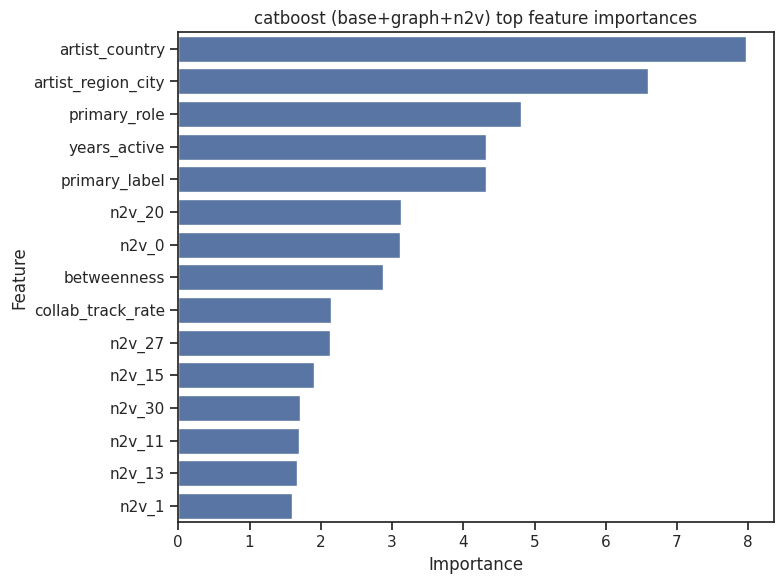

In [ ]:
if best_row["model"] == "catboost":
    importances = pd.Series(
        best_model.get_feature_importance(type="FeatureImportance"),
        index=feature_names,
    )
else:
    importances = pd.Series(best_model.feature_importances_, index=feature_names)

importances = importances.sort_values(ascending=False)
display(importances.to_frame("importance"))

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title(f"{best_row['model']} ({best_row['feature_set']}) top feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## SHAP summary plot for the best model

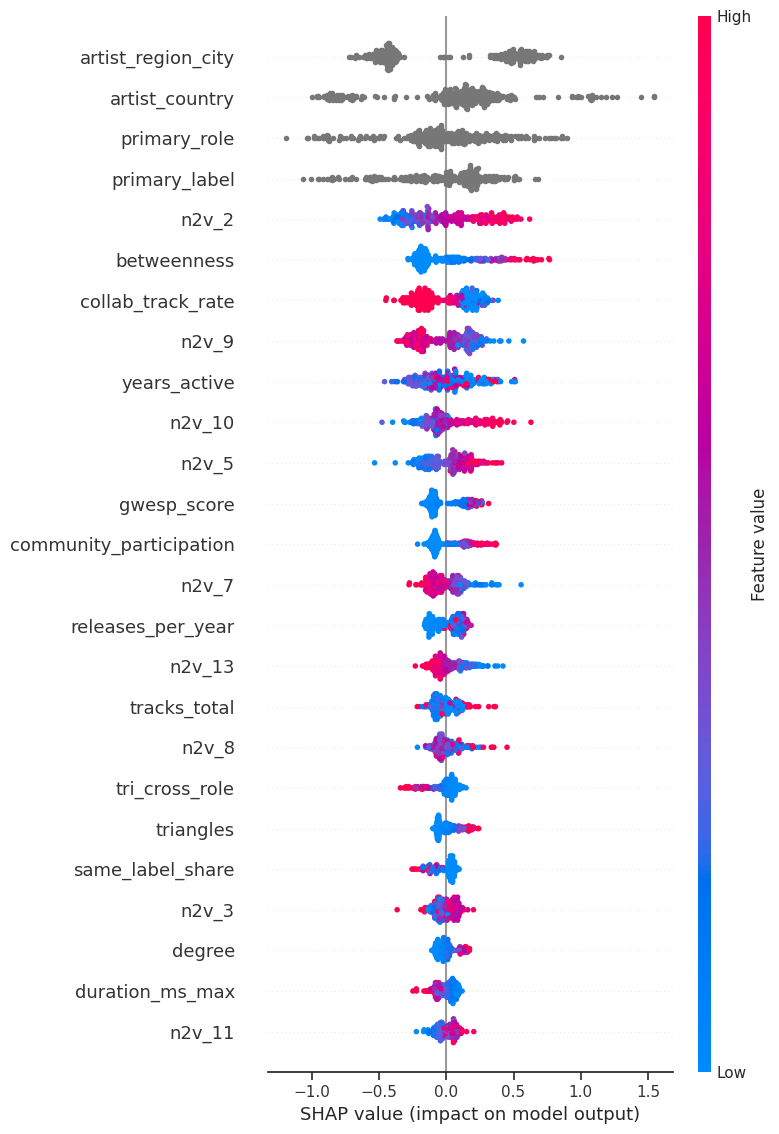

In [ ]:
sample = best_features.sample(
    n=min(300, len(best_features)), random_state=RANDOM_STATE
)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    features=sample,
    feature_names=feature_names,
    show=False,
    max_display=25,
)
plt.tight_layout()
plt.show()
